In [1]:
import numpy as np
import cmath
import matplotlib.pyplot as plt
import pde
from pde import DiffusionPDE, CartesianGrid, ScalarField, FieldCollection, MemoryStorage

In [2]:
L = 10.0
k = 2.0
grid = CartesianGrid([(-L, L)], 128, periodic=[False])

x = grid.axes_coords[0]  # x-coordinates of the grid points
x0 = -6.0  # x0 < 0
sigma = 0.8

# Initial Condition
gaussian = np.exp(-((x - x0)**2) / (2*(sigma)**2))  #gaussian term 
plane_re = np.cos(k*x) * gaussian  #real part of the plane wave
plane_im = np.sin(k*x) * gaussian  #imaginary part of the plane wave

# Normalizing Initial Condition
rho0 = plane_re**2 + plane_im**2
norm0 = np.trapz(rho0, x)
plane_re = plane_re / np.sqrt(norm0)
plane_im = plane_im / np.sqrt(norm0)

initial_cond_re = ScalarField(grid, plane_re)   #real part of the initial condition
initial_cond_im = ScalarField(grid, plane_im)   #imaginary part of the initial condition

state = FieldCollection([initial_cond_re, initial_cond_im], labels=["u", "v"])  #combine real and imaginary parts into a FieldCollection

In [3]:
# Boundary Conditions
k = 2.0
L = 10.0
hbar = 1.0  #scaled units for quantum PDE simulations
m = 1.0
omega = hbar * k**2 / (2 * m)
t = 10.0

# psi = lambda k,x : np.exp(1j * (k*x))  # plane wave solution, ref (1.1)

# old stuff
# # Real parts of Dirichlet and Robin
# bc_u = {"x-": {"value_expression": f"cos({k}*x - {omega}*t)"}, "x+": {"derivative": f"-{k} * v"}}  # Dirichlet at x=-L, Neumann at x=L

# # Imaginary parts of Dirichlet and Robin
# bc_v = {"x-": {"value_expression": f"sin({k}*x - {omega}*t)"}, "x+": {"derivative": f"{k} * u"}}  # Dirichlet at x=-L, Neumann at x=L

# new stuff
# BC operations combining parts of Dirichlet and Robin
bc = {
    "x-": {"derivative": 0},
    "x+": {"derivative": 0},
}

In [4]:
dx = x[1] - x[0]

def hook(state_data, t):
    u = state_data[0]
    v = state_data[1]

    # -------------------------
    # left boundary: Dirichlet
    # -------------------------
    theta = -k*L - omega*t
    u[0] = u[1]
    v[0] = v[1]

    # -------------------------
    # right boundary: coupled Robin
    # u_x = -k v
    # v_x =  k u
    # -------------------------
    c = dx * k
    denom = 1 + c**2

    u_in = u[-2]
    v_in = v[-2]

    u[-1] = (u_in - c*v_in) / denom
    v[-1] = (v_in + c*u_in) / denom

In [5]:
# Smoothed out Potential energy conditions for Interfaces

x_vals = np.linspace(-L, L, 1000)
a = 2.0  # width of the potential barrier
alpha = 10.0  # controls the steepness of the transition
v0 = 5.0  # height of the potential barrier

v_smooth = lambda x_vals, v0, a, alpha: 0.5 * v0 * (np.tanh(alpha * x_vals) - np.tanh(alpha * (x_vals-a))) 

In [6]:
# Governing equation / PDE

v_str = f"0.5 * {v0} * (tanh({alpha} * x) - tanh({alpha} * (x-{a})))"
# eq = pde.PDE({"psi": f"I * {hbar/(2*m)} * laplace(psi) - I / {hbar} * ({v_str}) * psi"})

eq = pde.PDE({
    "u": f"-( {hbar/(2*m)} ) * laplace(v) + ( ({v_str}) / {hbar} ) * v",
    "v": f"( {hbar/(2*m)} ) * laplace(u) - ( ({v_str}) / {hbar} ) * u"
}, bc = bc, post_step_hook=hook)

In [7]:
# result = eq.solve(state, t_range=t)
storage = MemoryStorage()
result = eq.solve(
    state,
    t_range=t,
    dt=1e-4,
    tracker=storage.tracker(0.1)
)

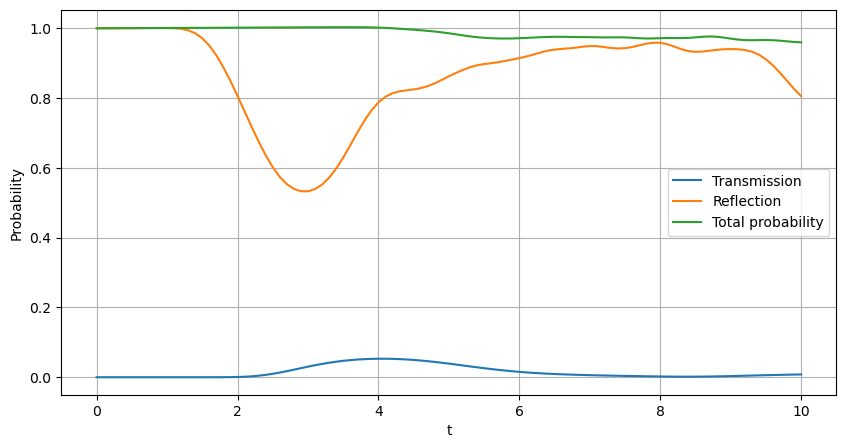

Final T = 0.00788546271071041
Final R = 0.8054144649689361
Final N = 0.9596793542844685


In [12]:
def probability_density(fields):
    u = fields[0].data
    v = fields[1].data
    return u**2 + v**2

def transmission_probability(fields, x, barrier_right_edge):
    rho = probability_density(fields)
    mask = x > barrier_right_edge + 0.5    # shift slightly right
    return np.trapz(rho[mask], x[mask])

def reflection_probability(fields, x, barrier_left_edge=0.0):
    rho = probability_density(fields)
    mask = x < barrier_left_edge - 0.5     # shift slightly left
    return np.trapz(rho[mask], x[mask])

def total_probability(fields, x):
    rho = probability_density(fields)
    return np.trapz(rho, x)

times, Tvals, Rvals, Nvals = [], [], [], []

for time, fields in storage.items():
    times.append(time)
    Tvals.append(transmission_probability(fields, x, a))
    Rvals.append(reflection_probability(fields, x, 0.0))
    Nvals.append(total_probability(fields, x))

plt.figure(figsize=(10, 5))
plt.plot(times, Tvals, label="Transmission")
plt.plot(times, Rvals, label="Reflection")
plt.plot(times, Nvals, label="Total probability")
plt.xlabel("t")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

print("Final T =", Tvals[-1])
print("Final R =", Rvals[-1])
print("Final N =", Nvals[-1])

In [11]:
def barrier_probability(fields, x, a):
    rho = probability_density(fields)
    mask = (x >= 0) & (x <= a)
    return np.trapz(rho[mask], x[mask])

Bvals = []

for time, fields in storage.items():
    Bvals.append(barrier_probability(fields, x, a))

print("Final Sum of probabilities (T + R + B) =", Tvals[-1] + Rvals[-1] + Bvals[-1])
print("Final Total Probability (N) =", Nvals[-1])

Final Sum of probabilities (T + R + B) = 0.8685848295361371
Final Total Probability (N) = 0.9596793542844685


In [14]:
a_values = np.linspace(1.0, 3.0, 12)
T_final = []
V0 = 5.0

for a_val in a_values:

    # recreate initial condition each time
    gaussian = np.exp(-((x - x0)**2) / (2*sigma**2))
    u_init = np.cos(k*x) * gaussian
    v_init = np.sin(k*x) * gaussian

    rho0 = u_init**2 + v_init**2
    norm0 = np.sum(rho0) * dx
    u_init /= np.sqrt(norm0)
    v_init /= np.sqrt(norm0)

    u_field = ScalarField(grid, u_init)
    v_field = ScalarField(grid, v_init)

    state = FieldCollection([u_field, v_field], labels=["u", "v"])

    # update barrier
    v_str = f"0.5 * {V0} * (tanh({alpha} * x) - tanh({alpha} * (x-{a_val})))"

    eq = pde.PDE({
        "u": f"-( {hbar/(2*m)} ) * laplace(v) + (({v_str})/{hbar}) * v",
        "v": f"( {hbar/(2*m)} ) * laplace(u) - (({v_str})/{hbar}) * u"
    }, bc=bc, post_step_hook=hook)

    result = eq.solve(state, t_range=t, dt=1e-4)

    # compute transmission at final time
    u = result["u"].data
    v = result["v"].data
    rho = u**2 + v**2

    T_val = np.sum(rho[x > a_val]) * dx
    T_final.append(T_val)

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

...

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

  0%|          | 0/10.0 [00:00<?, ?it/s]

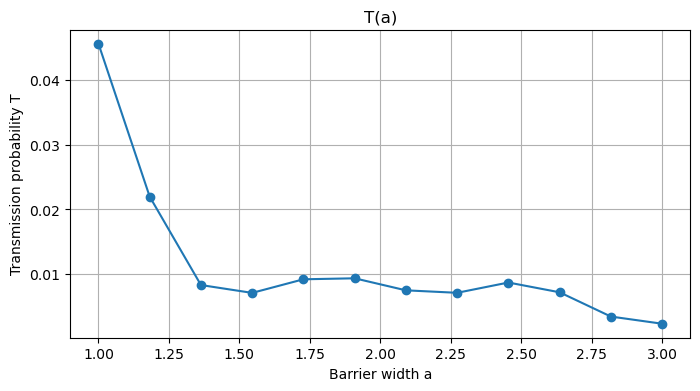

In [15]:
plt.figure(figsize=(8,4))
plt.plot(a_values, T_final, 'o-')
plt.xlabel("Barrier width a")
plt.ylabel("Transmission probability T")
plt.title("T(a)")
plt.grid(True)
plt.show()

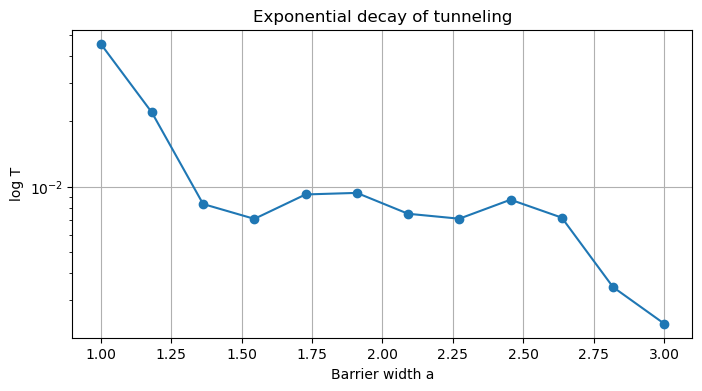

In [16]:
plt.figure(figsize=(8,4))
plt.semilogy(a_values, T_final, 'o-')
plt.xlabel("Barrier width a")
plt.ylabel("log T")
plt.title("Exponential decay of tunneling")
plt.grid(True)
plt.show()

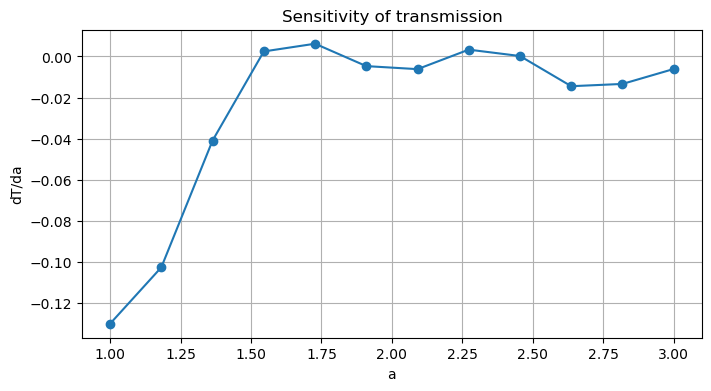

In [17]:
dT_da = np.gradient(T_final, a_values)

plt.figure(figsize=(8,4))
plt.plot(a_values, dT_da, 'o-')
plt.xlabel("a")
plt.ylabel("dT/da")
plt.title("Sensitivity of transmission")
plt.grid(True)
plt.show()